In [6]:
from mipt import *

Simulating p = 0.1
Simulating p = 0.1375
Simulating p = 0.175
Simulating p = 0.2125
Simulating p = 0.25


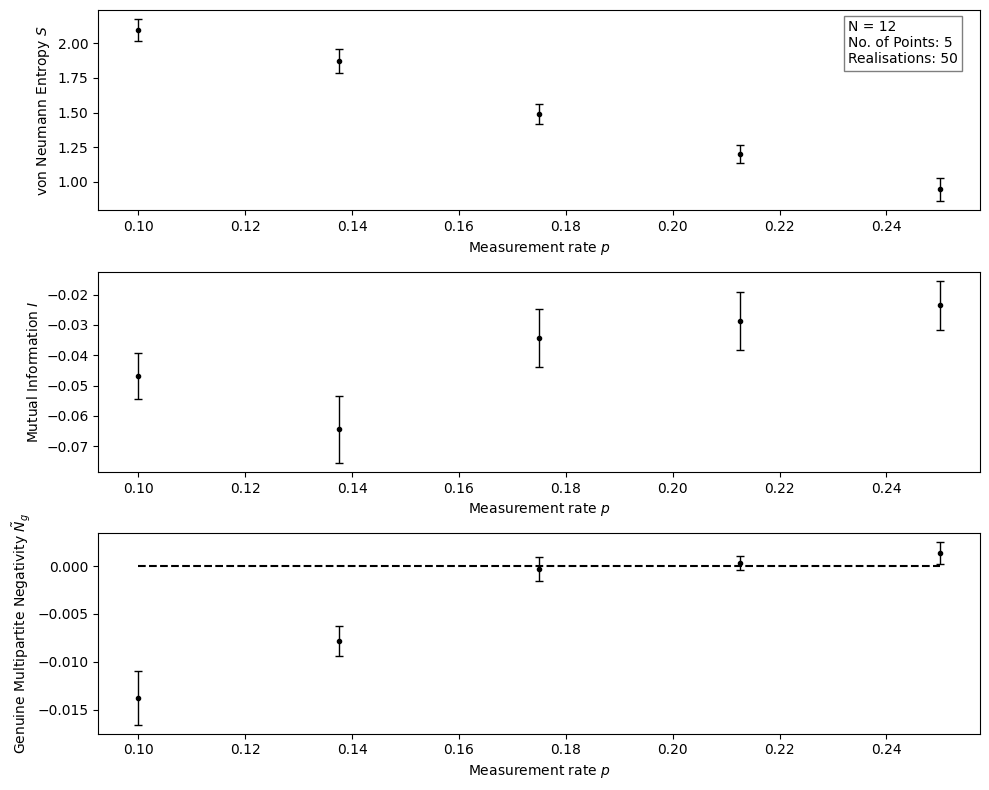

In [ ]:
n=14
d=2*n
res = 5
realisations = 50
ps, ents, ent_stds, mis, mi_stds, gmns, gmn_stds = run(n=n, d=d, res=res, realisations=realisations, p_min=0.1, p_max=0.25)

fig, [ax1, ax2, ax3] = plt.subplots(3, 1, figsize=(10, 8))

props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.85, 0.95, f"N = {n}\nNo. of Points: {res}\nRealisations: {realisations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

ax1.errorbar(ps, ents, yerr=ent_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax2.errorbar(ps, mis, yerr=mi_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax3.errorbar(ps, gmns, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax3.hlines(0, ps[0], ps[-1], colors='black', linestyles='dashed')
ax1.set_xlabel('Measurement rate $p$')
ax1.set_ylabel('von Neumann Entropy $S$')
ax2.set_xlabel('Measurement rate $p$')
ax2.set_ylabel('Mutual Information $I$')
ax3.set_xlabel('Measurement rate $p$')
ax3.set_ylabel(r'Genuine Multipartite Negativity $\tilde{N}_g$')
plt.tight_layout()

In [ ]:
x = 4
y = 4
d=4*(x*y)
res = 5
realisations = 5
ps, ents, ent_stds, mis, mi_stds, gmns, gmn_stds = run_2d(x=x, y=y, d=d, res=res, realisations=realisations, p_min=0.0, p_max=0.5)

fig, [ax1, ax2, ax3] = plt.subplots(3, 1, figsize=(10, 8))

props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.85, 0.95, f"x = {x}, y = {y}\nNo. of Points: {res}\nRealisations: {realisations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

ax1.errorbar(ps, ents, yerr=ent_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax2.errorbar(ps, mis, yerr=mi_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax3.errorbar(ps, gmns, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax3.hlines(0, ps[0], ps[-1], colors='black', linestyles='dashed')
ax1.set_xlabel('Measurement rate $p$')
ax1.set_ylabel('von Neumann Entropy $S$')
ax2.set_xlabel('Measurement rate $p$')
ax2.set_ylabel('Mutual Information $I$')
ax3.set_xlabel('Measurement rate $p$')
ax3.set_ylabel(r'Genuine Multipartite Negativity $\tilde{N}_g$')
plt.tight_layout()

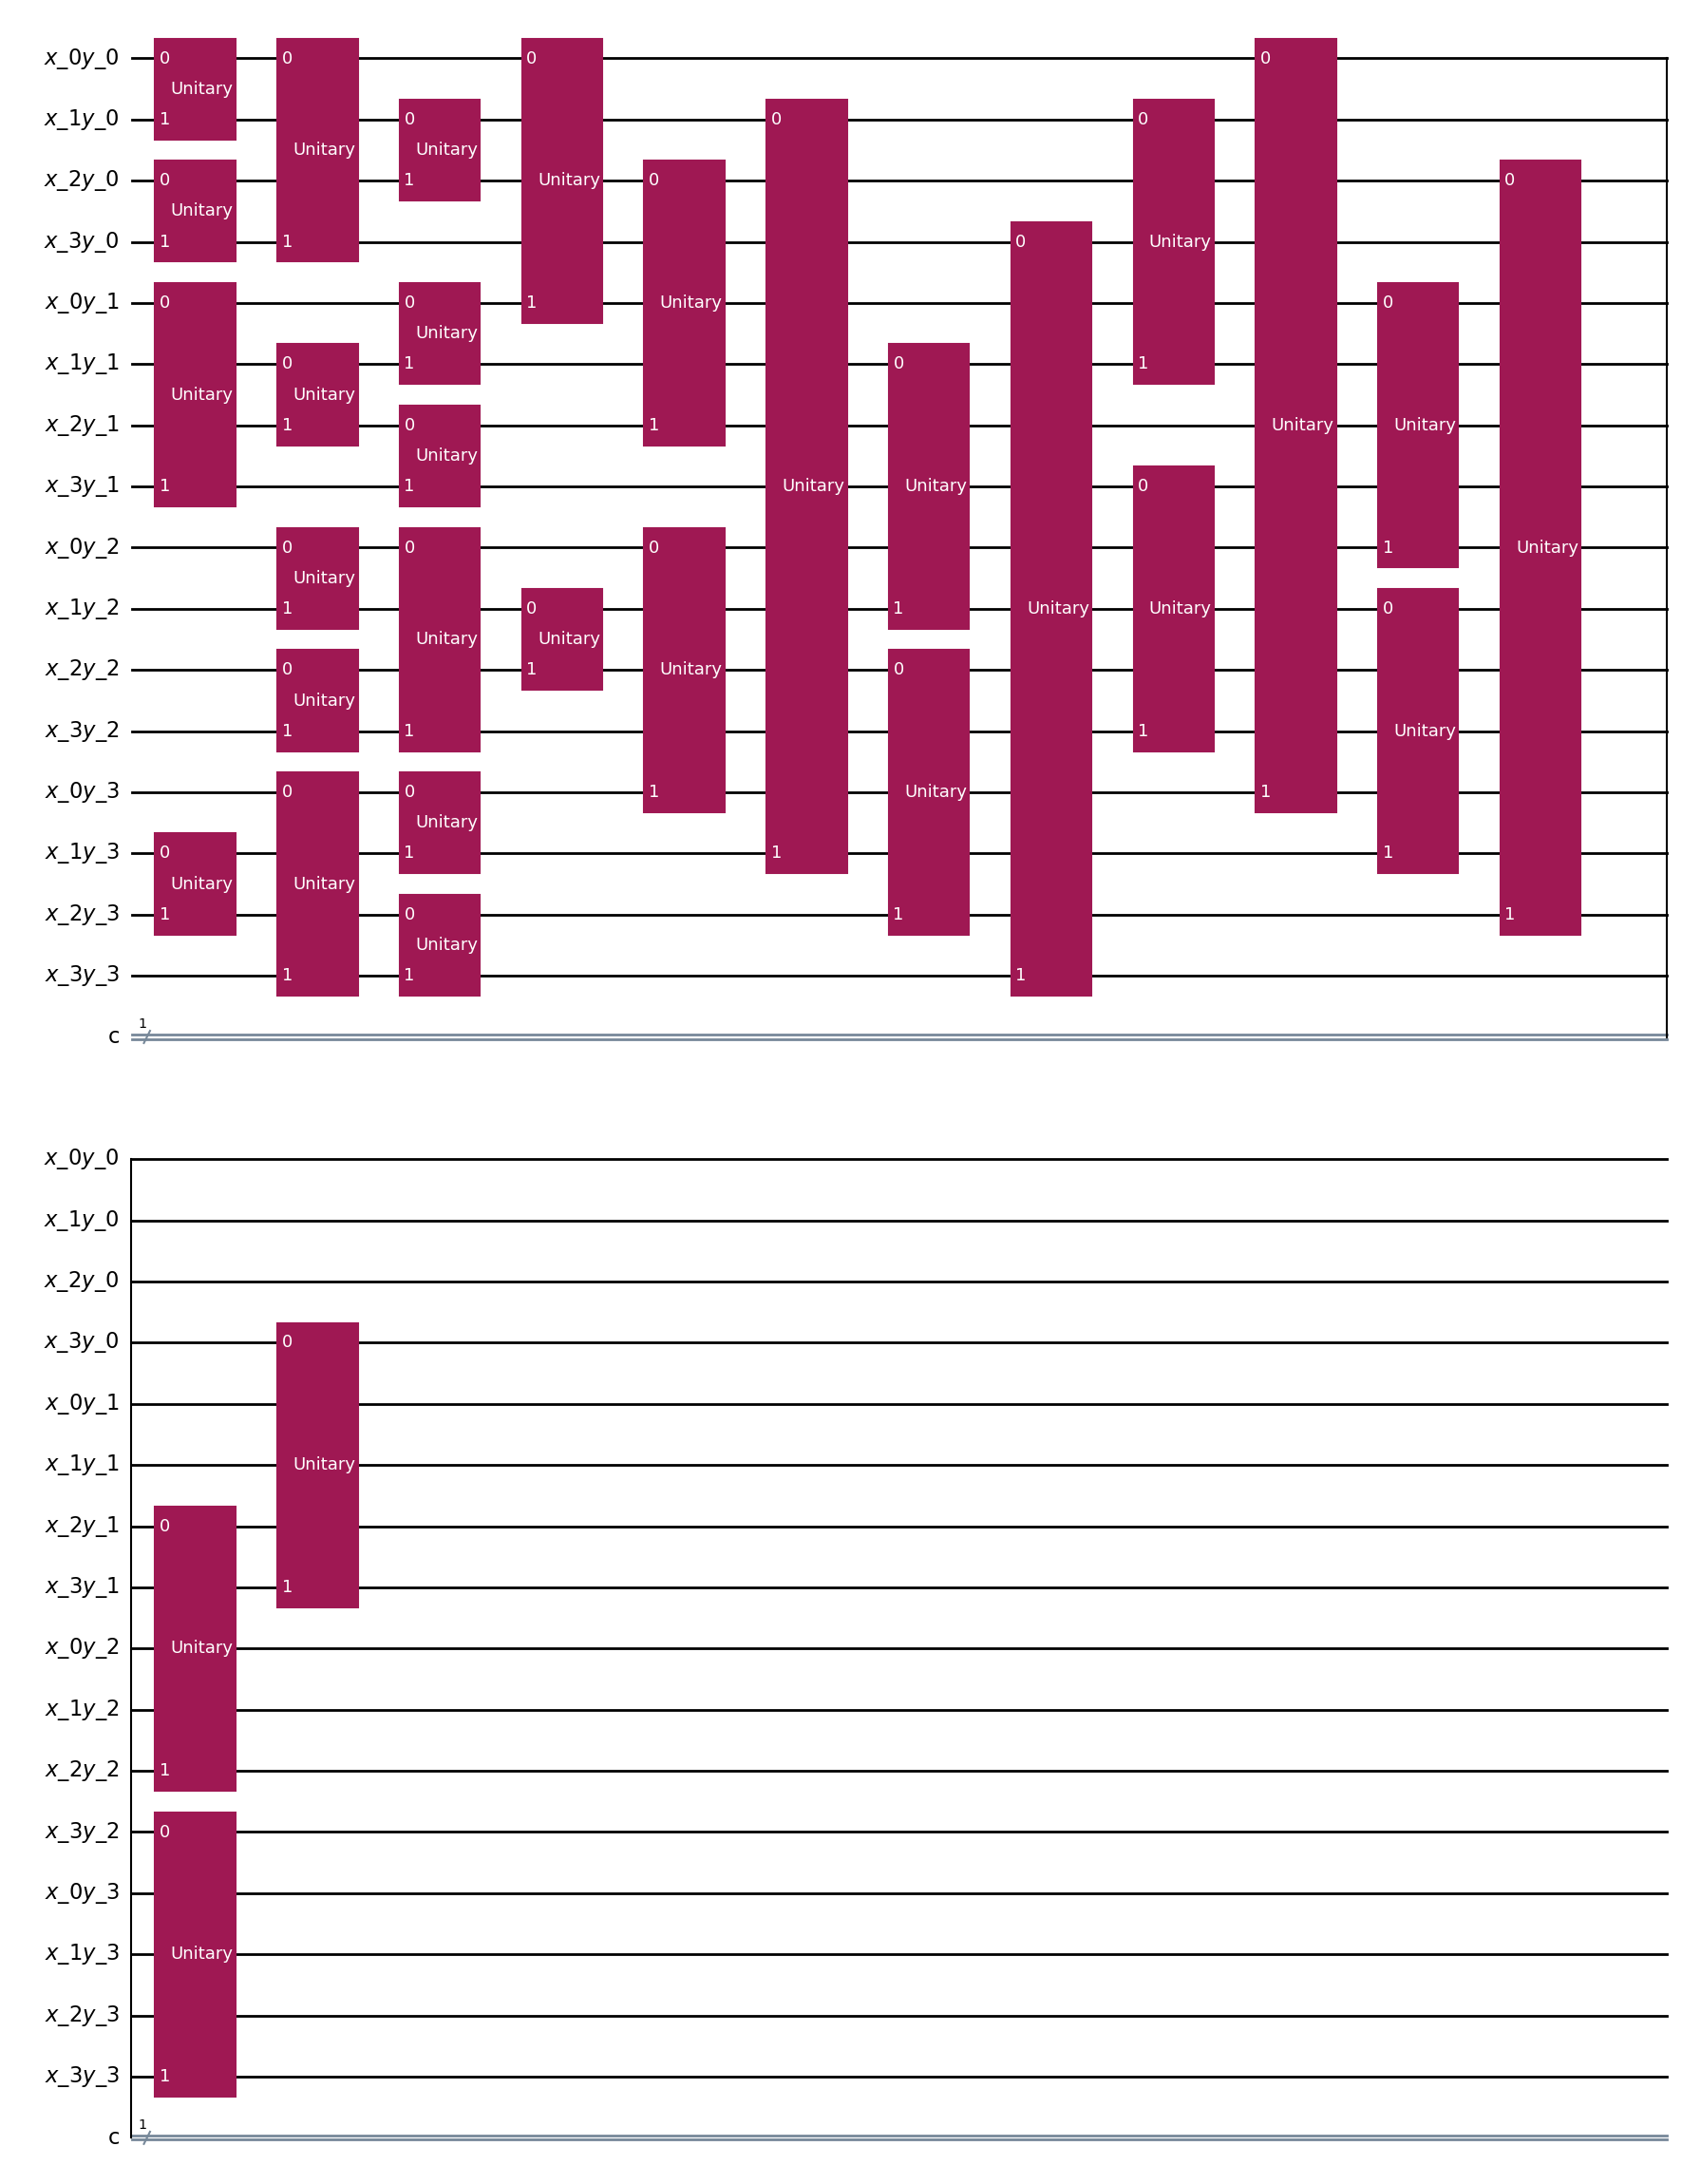

: 

In [ ]:
from mipt import *

qc = random_mipt_2d(x=4, y=4, d=4, p=0)
qc.draw('mpl')
# qc.save_statevector(label='final_state')
# backend = AerSimulator(device='GPU')
# transpiled_qc = transpile(qc, backend)
# result = backend.run(transpiled_qc).result()
# saved_state = result.data(0)['final_state']

# rho = partial_trace(saved_state, [i for i in range(4*4 - 3)])
# print(gmn(rho))

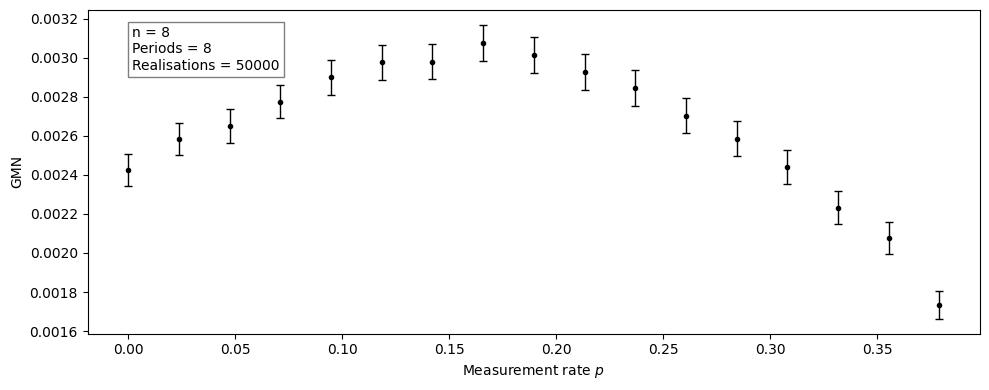

In [7]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

df = pd.read_csv('data.csv')
data_array = df.to_numpy().transpose()
ps = data_array[0]
# tmi_values = data_array[1]
gmn_values = data_array[1]

df2 = pd.read_csv('info.csv')
data_array2 = df2.to_numpy().transpose()
n = int(data_array2[0][0])
periods = int(data_array2[1][0])
realizations = int(data_array2[2][0])
res = int(data_array2[3][0])
p_min = float(data_array2[4][0])
p_max = float(data_array2[5][0])

ps_unique = list(set(ps))
# tmi_means = []
# tmi_stds = []
gmn_means = []
gmn_stds = []
for p in ps_unique:
    # tmi_values_for_p = [tmi for tmi, p_val in zip(tmi_values, ps) if p_val == p]
    # tmi_means.append(np.mean(tmi_values_for_p))
    # tmi_stds.append(np.std(tmi_values_for_p)/np.sqrt(realizations))
    gmn_values_for_p = [gmn for gmn, p_val in zip(gmn_values, ps) if p_val == p]
    gmn_means.append(np.mean(gmn_values_for_p))
    gmn_stds.append(np.std(gmn_values_for_p)/np.sqrt(realizations))

fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
ax1.errorbar(ps_unique, gmn_means, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
# ax2.errorbar(ps_unique, gmn_means, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax1.set_xlabel('Measurement rate $p$')
ax1.set_ylabel('GMN')
# ax2.set_ylabel('GMN')

props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.05, 0.95, f"n = {n}\nPeriods = {periods}\nRealisations = {realizations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
 
fig.tight_layout()

In [13]:
import cvxpy as cp
import numpy as np
from itertools import combinations


# ------------------------------------------------------------
# Convert Qiskit DensityMatrix / Statevector to numpy matrix
# ------------------------------------------------------------
def to_numpy_density_matrix(rho):
    rho = np.asarray(getattr(rho, "data", rho), dtype=complex)

    if rho.ndim == 1:  # statevector
        rho = np.outer(rho, rho.conj())

    return rho


# ------------------------------------------------------------
# Build partial transpose as a LINEAR MAP on vec(W)
# ------------------------------------------------------------
def partial_transpose_map(dims, sys):
    """
    Returns matrix PT such that:
        vec(W^T_sys) = PT @ vec(W)
    """
    d = int(np.prod(dims))
    dim2 = d * d

    PT = np.zeros((dim2, dim2), dtype=float)

    # basis element E_ij
    for i in range(d):
        for j in range(d):

            E = np.zeros((d, d))
            E[i, j] = 1.0

            # reshape into tensor form
            tensor = E.reshape(dims + dims)

            N = len(dims)
            axes = list(range(2 * N))

            for s in sys:
                axes[s], axes[s + N] = axes[s + N], axes[s]

            pt = tensor.transpose(axes).reshape(d, d)

            col = i * d + j
            PT[:, col] = pt.flatten()

    return PT


# ------------------------------------------------------------
# GMNN SDP
# ------------------------------------------------------------
def gmnn_sdp(rho, dims, k_minus_1=2, verbose=True):
    """
    GMNN witness SDP relaxation.

    Parameters:
    - rho: density matrix (Qiskit or numpy)
    - dims: subsystem dimensions, e.g. [2,2,2]
    - k_minus_1: max hyperedge size (2 = bipartite resources)
    """

    rho = to_numpy_density_matrix(rho)
    d = rho.shape[0]

    parties = list(range(len(dims)))

    # --------------------------------------------------------
    # Build allowed subsystem structure (hyperedges)
    # --------------------------------------------------------
    edges = []
    for r in range(1, k_minus_1 + 1):
        edges += list(combinations(parties, r))

    # --------------------------------------------------------
    # SDP variable: entanglement witness
    # --------------------------------------------------------
    W = cp.Variable((d, d), hermitian=True)

    constraints = []

    # --------------------------------------------------------
    # Constraint 1: upper bound (stability / normalization)
    # --------------------------------------------------------
    constraints += [W << np.eye(d)]

    # --------------------------------------------------------
    # Constraint 2: positivity of partial transposes
    # (network-relaxed PPT constraints)
    # --------------------------------------------------------
    W_vec = cp.vec(W, order="C")

    for S in edges:
        PT = partial_transpose_map(dims, S)

        W_pt = cp.reshape(PT @ W_vec, (d, d), order="C")

        constraints += [W_pt >> 0]

    # --------------------------------------------------------
    # Objective: GMNN witness value
    # --------------------------------------------------------
    objective = cp.Minimize(cp.real(cp.trace(rho @ W)))

    prob = cp.Problem(objective, constraints)

    prob.solve(solver=cp.MOSEK)

    gmnn_value = -prob.value

    return gmnn_value, W.value

n=8
d=2*n
p=0.17
qc = random_mipt_1d(n, d, p, closed=True)
qc.save_statevector(label='final_state')
transpiled_qc = transpile(qc, backend)
result = backend.run(transpiled_qc).result()
saved_state = result.data(0)['final_state']
sub_m = partial_trace(saved_state, [i for i in range(n-3)])

gmnn_value, W_opt = gmnn_sdp(sub_m, dims=[2,2,2], k_minus_1=2)
print("GMNN value:", gmnn_value)

GMNN value: 0.10796417856881455


Simulating p = 0.05
Simulating p = 0.125
Simulating p = 0.2
Simulating p = 0.27499999999999997
Simulating p = 0.35


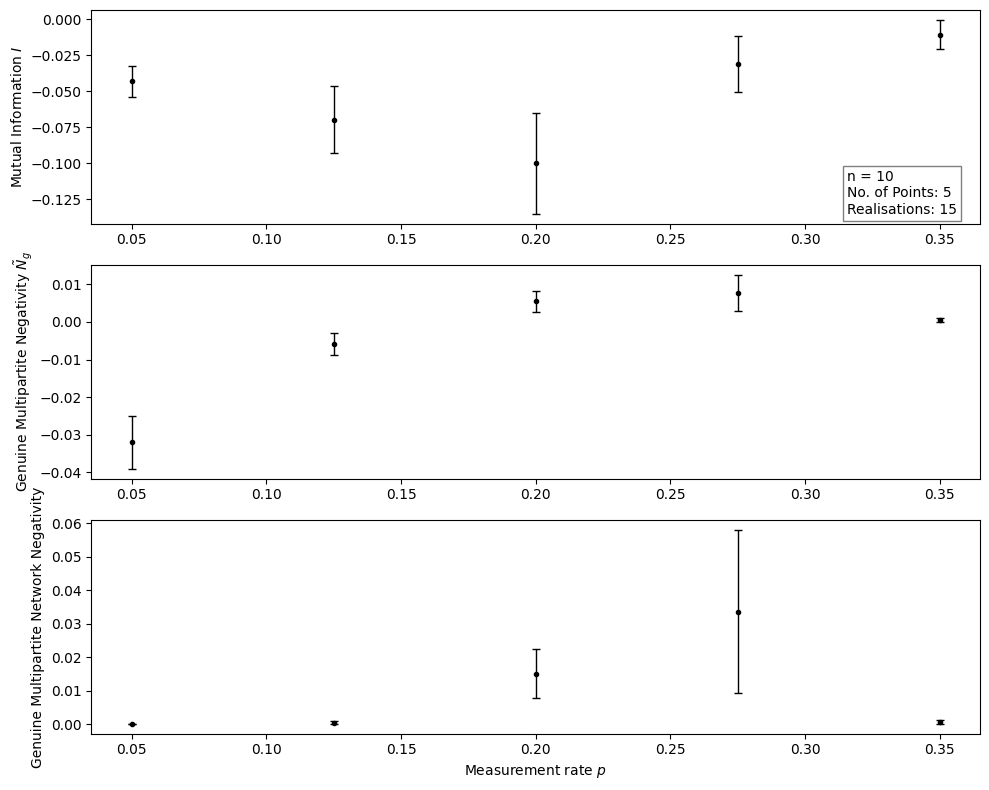

In [10]:
from mipt import *

n=10
d=2*n
res = 5
realisations = 15
ps, ents, ent_stds, mis, mi_stds, gmns, gmn_stds, gmnns, gmnn_stds = run_1d(n=n, d=d, res=res, 
                                                                            realisations=realisations, p_min=0.05, p_max=0.35)


fig, [ax1, ax2, ax3] = plt.subplots(3, 1, figsize=(10, 8))
props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.85, 0.25, f"n = {n}\nNo. of Points: {res}\nRealisations: {realisations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

ax1.errorbar(ps, mis, yerr=mi_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax2.errorbar(ps, gmns, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax3.errorbar(ps, gmnns, yerr=gmnn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax1.set_ylabel('Mutual Information $I$')
ax2.set_ylabel(r'Genuine Multipartite Negativity $\tilde{N}_g$')
ax3.set_xlabel('Measurement rate $p$')
ax3.set_ylabel('Genuine Multipartite Network Negativity')
plt.tight_layout()

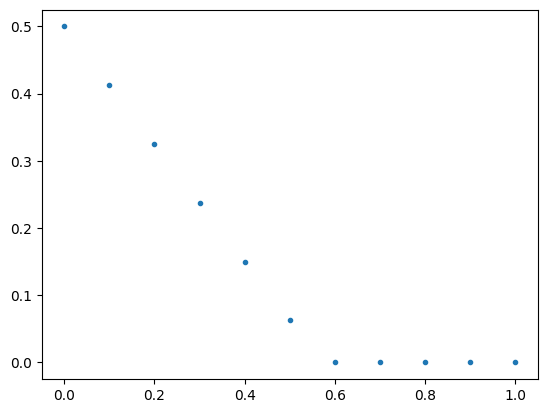

In [2]:
from mipt import *
import numpy as np
from numpy.typing import NDArray
from scipy.optimize import curve_fit

Array = NDArray[np.complex128]

def ketbra(psi: Array) -> Array:
    psi = np.asarray(psi, dtype=np.complex128).reshape(-1)
    nrm = np.linalg.norm(psi)

    if nrm <= 1e-15:
        raise ValueError("Cannot form ketbra from a zero vector.")

    psi = psi / nrm
    return np.outer(psi, psi.conj()).astype(np.complex128)

def ghz3_density() -> Array:
    psi = np.zeros(8, dtype=np.complex128)
    psi[0] = 1.0 / np.sqrt(2)
    psi[7] = 1.0 / np.sqrt(2)
    return ketbra(psi)

def ghz4_density() -> Array:
    psi = np.zeros(16, dtype=np.complex128)
    psi[0] = 1.0 / np.sqrt(2)
    psi[15] = 1.0 / np.sqrt(2)
    return ketbra(psi)

ps = np.linspace(0, 1, 11)
gmn_values = []
for p in ps:
    rho = (1-p) * ghz3_density() + p * np.eye(8) / 8
    gmn_values.append(gmn(rho))

# def gmn_fit_func(p, a, b):
#     return a*p + b

# params, pcov = curve_fit(gmn_fit_func, ps, gmn_values, p0=[1.0, 1.0])
# print("Fitted parameters:", params)
plt.plot(ps, gmn_values, '.')


In [7]:
parties = 4
partitions = {chr(ord('A') + i): [i] for i in range(parties)}
print(partitions)

{'A': [0], 'B': [1], 'C': [2], 'D': [3]}


Simulating p = 0.0
Simulating p = 0.125
Simulating p = 0.25
Simulating p = 0.375
Simulating p = 0.5


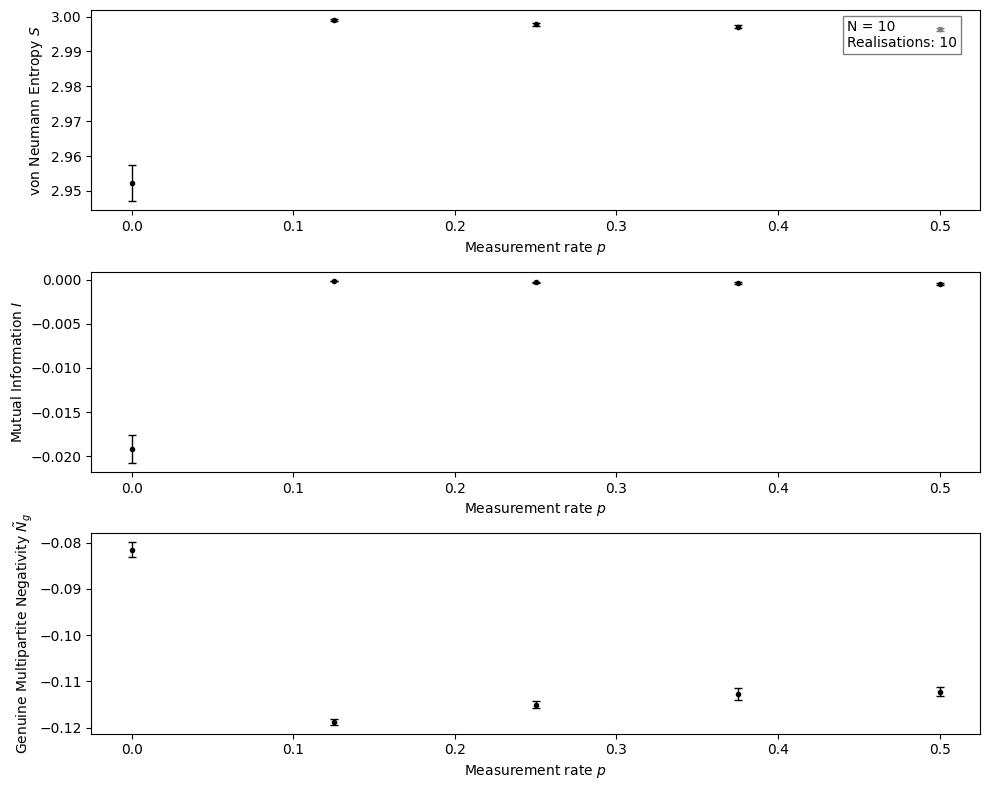

In [1]:
from mipt import *

n=10
d=2*n
res = 5
realisations = 10
ps, ents, ent_stds, mis, mi_stds, gmns, gmn_stds = run_1d_p_scan(n=n, depth=d, res=res, 
                                                        realisations=realisations, p_min=0.0, p_max=0.5, use_gpu=True)

fig, [ax1, ax2, ax3] = plt.subplots(3, 1, figsize=(10, 8))

props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.85, 0.95, f"N = {n}\nRealisations: {realisations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

ax1.errorbar(ps, ents, yerr=ent_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax2.errorbar(ps, mis, yerr=mi_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax3.errorbar(ps, gmns, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
# ax3.hlines(0, ps[0], ps[-1], colors='black', linestyles='dashed')
ax1.set_xlabel('Measurement rate $p$')
ax1.set_ylabel('von Neumann Entropy $S$')
ax2.set_xlabel('Measurement rate $p$')
ax2.set_ylabel('Mutual Information $I$')
ax3.set_xlabel('Measurement rate $p$')
ax3.set_ylabel(r'Genuine Multipartite Negativity $\tilde{N}_g$')
plt.tight_layout()

Simulating p = 0.05
Simulating d = 1
Simulating d = 2
Simulating d = 3
Simulating p = 0.1625
Simulating d = 1
Simulating d = 2
Simulating d = 3
Simulating p = 0.275
Simulating d = 1
Simulating d = 2
Simulating d = 3
Simulating p = 0.3875
Simulating d = 1
Simulating d = 2
Simulating d = 3
Simulating p = 0.5
Simulating d = 1
Simulating d = 2
Simulating d = 3


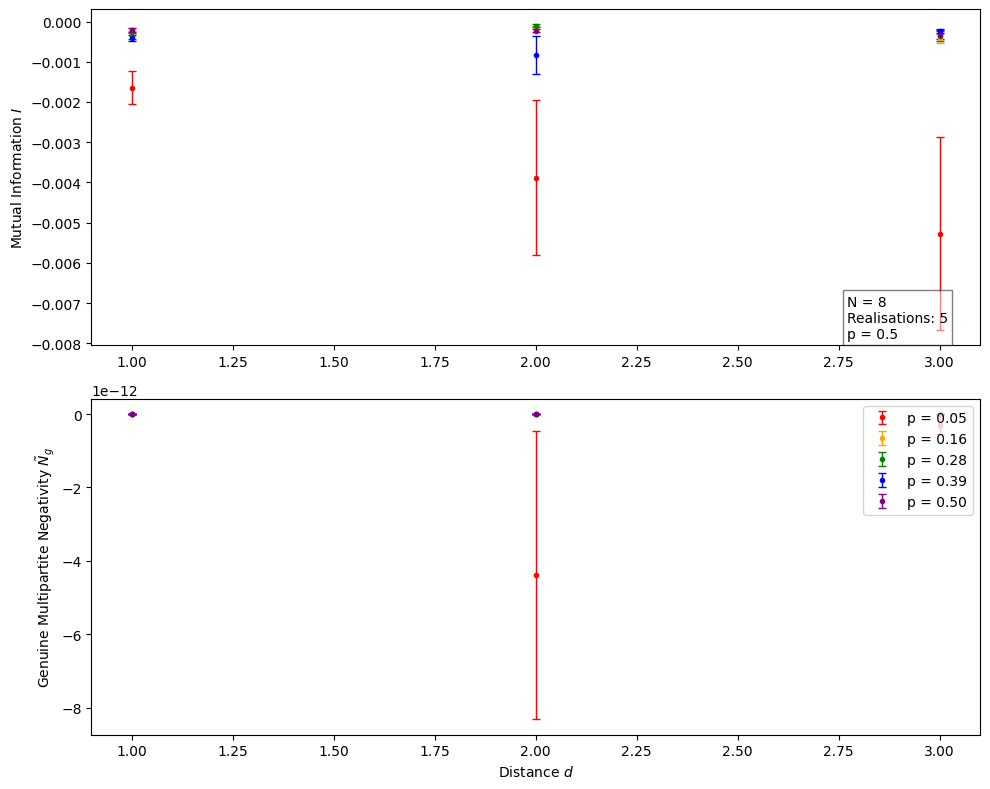

In [4]:
from mipt import *

n = 8
depth = 2*n
ps = np.linspace(0.05, 0.5, 5)
realisations = 5

mi_list, mi_std_list, gmn_list, gmn_std_list = [], [], [], []

for p in ps:
        print("Simulating p =", p)
        d_values, ents, ent_stds, mis, mi_stds, gmns, gmn_stds = run_1d_distance_scan(
                n, depth, p, realisations, d_min=1, d_max=3, use_gpu=False)

        mi_list.append(mis)
        mi_std_list.append(mi_stds)
        gmn_list.append(gmns)
        gmn_std_list.append(gmn_stds)



fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(10, 8))

props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.85, 0.15, f"N = {n}\nRealisations: {realisations}\np = {p}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

colors = ["red", "orange", "green", "blue", "purple"]
for i in range(len(ps)):        
        ax1.errorbar(d_values, mi_list[i], yerr=mi_std_list[i], fmt='.', color=colors[i], ecolor=colors[i], capsize=3, elinewidth=1)
        ax2.errorbar(d_values, gmn_list[i], yerr=gmn_std_list[i], fmt='.', color=colors[i], ecolor=colors[i], capsize=3, elinewidth=1, label= f"p = {ps[i]:.2f}")
# ax3.hlines(0, d_values[0], d_values[-1], colors='black', linestyles='dashed')
ax2.set_xlabel('Distance $d$')
ax1.set_ylabel('Mutual Information $I$')
ax2.set_ylabel(r'Genuine Multipartite Negativity $\tilde{N}_g$')
ax2.legend(loc='upper right')
plt.tight_layout()